# 04 — Baseline Models
**BanglaCyberBench: A Robust Multi-Source Benchmark and Transformer Ensemble for Cyberbullying Detection in Bengali**

This notebook trains baseline models on the random split:
1. **TF-IDF + Logistic Regression**
2. **TF-IDF + SVM (LinearSVC)**
3. **TF-IDF + Random Forest**
4. **BiLSTM** (neural baseline with fastText/random embeddings)

All models are evaluated with: Macro-F1, Weighted-F1, Accuracy, MCC, per-class P/R/F1, and confusion matrix.

**Prerequisites:** Run notebooks 02 & 03 first.

In [1]:
! pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu118



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, matthews_corrcoef, roc_auc_score
)
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../outputs/baselines", exist_ok=True)

In [3]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())   # Must return True
print(torch.cuda.device_count())

2.6.0+cu124
True
1


In [4]:
# ── Load splits ────────────────────────────────────────────────────────────
# FOCUS CHANGE: baselines now target the 9-class ABUSE-TYPE task (the paper's
# primary focus), not binary. We consolidate the raw label_type into the same
# 9 canonical classes used by NB05 so baselines and transformers are comparable.
SPLIT_DIR = "../data/splits"
TEXT_COL  = "text_clean"
LABEL_COL = "label_type"   # ← 9-class abuse-type is now the primary baseline task

train_df = pd.read_csv(f"{SPLIT_DIR}/random_train.csv")
val_df   = pd.read_csv(f"{SPLIT_DIR}/random_val.csv")
test_df  = pd.read_csv(f"{SPLIT_DIR}/random_test.csv")

print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

# ── Consolidate raw label_type → 9 canonical classes (same rule as NB05) ─────
PRIORITY = ["threat","sexual","religious","gender","political",
            "abusive","personal","other","none"]
def consolidate_type(raw):
    if not isinstance(raw, str) or not raw.strip():
        return "none"
    s = raw.lower().replace("_"," ").replace(";",",")
    blob = " ".join(p.strip() for p in s.split(","))
    if any(k in blob for k in ["threat","calltoviolence"]):       return "threat"
    if "sexual" in blob:                                          return "sexual"
    if "religious" in blob or "religion" in blob:                 return "religious"
    if "gender" in blob:                                          return "gender"
    if "political" in blob:                                       return "political"
    if "abusive" in blob or "violence" in blob or "troll" in blob:return "abusive"
    if any(k in blob for k in ["personal","slander","origin","body","misc"]):
        return "personal"
    if "spam" in blob:                                            return "other"
    if "not bully" in blob or "none" in blob:                     return "none"
    return "personal"

for d in (train_df, val_df, test_df):
    d["label_type"] = d["label_type"].apply(consolidate_type)

# Encode 9 classes to integers (fixed canonical order, alphabetical for stability)
CANON9 = sorted(["abusive","gender","none","other","personal",
                 "political","religious","sexual","threat"])
LABEL2ID = {c: i for i, c in enumerate(CANON9)}
ID2LABEL = {i: c for c, i in LABEL2ID.items()}
print(f"\n9-class encoding: {LABEL2ID}")

X_train = train_df[TEXT_COL].fillna("").values
X_val   = val_df[TEXT_COL].fillna("").values
X_test  = test_df[TEXT_COL].fillna("").values

y_train = train_df[LABEL_COL].map(LABEL2ID).values
y_val   = val_df[LABEL_COL].map(LABEL2ID).values
y_test  = test_df[LABEL_COL].map(LABEL2ID).values

NUM_CLASSES = len(CANON9)
print(f"\nNum classes: {NUM_CLASSES}")
print(f"Train class dist: {dict(pd.Series(y_train).map(ID2LABEL).value_counts())}")
print(f"Test  class dist: {dict(pd.Series(y_test).map(ID2LABEL).value_counts())}")


Train: 75,469  Val: 9,434  Test: 9,434

Train class dist: {0: np.int64(37884), 1: np.int64(37585)}
Val   class dist: {1: np.int64(4734), 0: np.int64(4700)}
Test  class dist: {0: np.int64(4740), 1: np.int64(4694)}


## 1 — TF-IDF Feature Extraction

In [5]:
# ── TF-IDF (word + char n-grams for Bangla) ───────────────────────────────
# Word-level
tfidf_word = TfidfVectorizer(
    analyzer="word",
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
)

# Character-level (good for Bangla morphology & Banglish)
tfidf_char = TfidfVectorizer(
    analyzer="char_wb",
    max_features=50000,
    ngram_range=(2, 5),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
)

from scipy.sparse import hstack

X_train_word = tfidf_word.fit_transform(X_train)
X_val_word   = tfidf_word.transform(X_val)
X_test_word  = tfidf_word.transform(X_test)

X_train_char = tfidf_char.fit_transform(X_train)
X_val_char   = tfidf_char.transform(X_val)
X_test_char  = tfidf_char.transform(X_test)

# Combine word + char features
X_train_tfidf = hstack([X_train_word, X_train_char])
X_val_tfidf   = hstack([X_val_word, X_val_char])
X_test_tfidf  = hstack([X_test_word, X_test_char])

print(f"TF-IDF feature dim: {X_train_tfidf.shape[1]:,}")
print(f"  Word features: {X_train_word.shape[1]:,}")
print(f"  Char features: {X_train_char.shape[1]:,}")

TF-IDF feature dim: 100,000
  Word features: 50,000
  Char features: 50,000


## 2 — ML Baselines

### Helper: Evaluation Function

In [6]:
all_results = []

def evaluate_model(name, y_true, y_pred, y_prob=None, split="test"):
    """Evaluate and print metrics for a model."""
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    mcc = matthews_corrcoef(y_true, y_pred)
    
    auc = None
    if y_prob is not None:
        try:
            import numpy as _np
            yp = _np.asarray(y_prob)
            if yp.ndim == 2 and yp.shape[1] > 2:
                auc = roc_auc_score(y_true, yp, multi_class='ovr', average='macro',
                                    labels=list(range(yp.shape[1])))
            elif yp.ndim == 2:
                auc = roc_auc_score(y_true, yp[:, 1])
            else:
                auc = roc_auc_score(y_true, yp)
        except Exception:
            pass
    
    result = {
        "model": name,
        "split": split,
        "accuracy": round(acc, 4),
        "macro_f1": round(macro_f1, 4),
        "weighted_f1": round(weighted_f1, 4),
        "mcc": round(mcc, 4),
    }
    if auc is not None:
        result["auroc"] = round(auc, 4)
    
    all_results.append(result)
    
    print(f"\n{'='*50}")
    print(f"{name} — {split}")
    print(f"{'='*50}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Macro-F1    : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted-F1 : {weighted_f1:.4f}")
    print(f"  MCC         : {mcc:.4f}")
    if auc is not None:
        print(f"  AUROC       : {auc:.4f}")
    print(f"\n{classification_report(y_true, y_pred, digits=4)}")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Harmful", "Harmful"],
                yticklabels=["Not Harmful", "Harmful"])
    ax.set_title(f"{name} — Confusion Matrix ({split})", fontweight="bold")
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")
    plt.tight_layout()
    safe_name = name.replace(" ", "_").replace("+", "_").replace("/", "_")
    plt.savefig(f"../outputs/baselines/cm_{safe_name}_{split}.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    return result

### 2.1 — Logistic Regression


TF-IDF + Logistic Regression — test
  Accuracy    : 0.8513
  Macro-F1    : 0.8511  ← PRIMARY METRIC
  Weighted-F1 : 0.8512
  MCC         : 0.7034
  AUROC       : 0.9307

              precision    recall  f1-score   support

           0     0.8350    0.8774    0.8557      4740
           1     0.8695    0.8249    0.8466      4694

    accuracy                         0.8513      9434
   macro avg     0.8522    0.8512    0.8511      9434
weighted avg     0.8522    0.8513    0.8512      9434



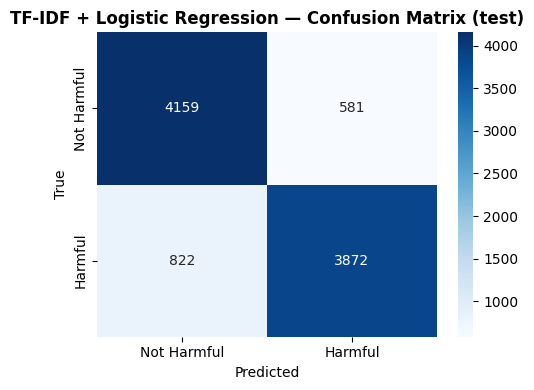

{'model': 'TF-IDF + Logistic Regression',
 'split': 'test',
 'accuracy': 0.8513,
 'macro_f1': 0.8511,
 'weighted_f1': 0.8512,
 'mcc': 0.7034,
 'auroc': 0.9307}

In [7]:
lr = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight="balanced",
    random_state=SEED,
    solver="lbfgs"
)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
y_prob_lr = lr.predict_proba(X_test_tfidf)  # full (N, C) for multiclass AUROC
evaluate_model("TF-IDF + Logistic Regression", y_test, y_pred_lr, y_prob_lr)

### 2.2 — Linear SVM


TF-IDF + SVM — test
  Accuracy    : 0.8482
  Macro-F1    : 0.8481  ← PRIMARY METRIC
  Weighted-F1 : 0.8481
  MCC         : 0.6973
  AUROC       : 0.9255

              precision    recall  f1-score   support

           0     0.8312    0.8757    0.8529      4740
           1     0.8673    0.8204    0.8432      4694

    accuracy                         0.8482      9434
   macro avg     0.8493    0.8481    0.8481      9434
weighted avg     0.8492    0.8482    0.8481      9434



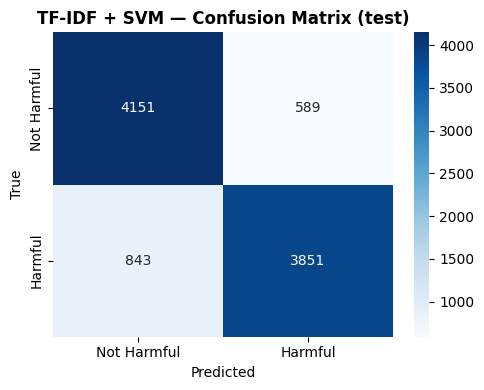

{'model': 'TF-IDF + SVM',
 'split': 'test',
 'accuracy': 0.8482,
 'macro_f1': 0.8481,
 'weighted_f1': 0.8481,
 'mcc': 0.6973,
 'auroc': 0.9255}

In [8]:
svm_base = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=SEED,
    max_iter=5000
)
# Wrap with CalibratedClassifierCV to get probability estimates
svm = CalibratedClassifierCV(svm_base, cv=3)
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)
y_prob_svm = svm.predict_proba(X_test_tfidf)  # full (N, C)
evaluate_model("TF-IDF + SVM", y_test, y_pred_svm, y_prob_svm)

### 2.3 — Random Forest


TF-IDF + Random Forest — test
  Accuracy    : 0.8284
  Macro-F1    : 0.8283  ← PRIMARY METRIC
  Weighted-F1 : 0.8283
  MCC         : 0.6572
  AUROC       : 0.9137

              precision    recall  f1-score   support

           0     0.8170    0.8485    0.8325      4740
           1     0.8408    0.8081    0.8241      4694

    accuracy                         0.8284      9434
   macro avg     0.8289    0.8283    0.8283      9434
weighted avg     0.8288    0.8284    0.8283      9434



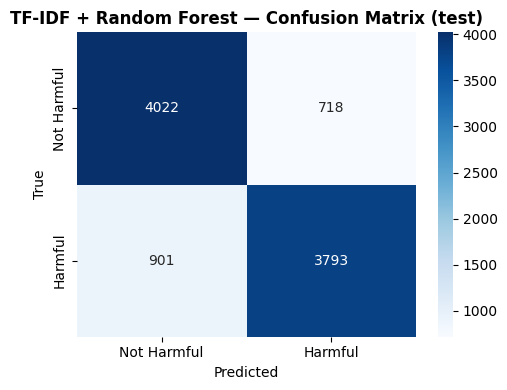

{'model': 'TF-IDF + Random Forest',
 'split': 'test',
 'accuracy': 0.8284,
 'macro_f1': 0.8283,
 'weighted_f1': 0.8283,
 'mcc': 0.6572,
 'auroc': 0.9137}

In [9]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train_tfidf, y_train)

y_pred_rf = rf.predict(X_test_tfidf)
y_prob_rf = rf.predict_proba(X_test_tfidf)  # full (N, C)
evaluate_model("TF-IDF + Random Forest", y_test, y_pred_rf, y_prob_rf)

## 3 — BiLSTM Neural Baseline

A simple BiLSTM with an embedding layer, trained with class-balanced loss.

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Force CUDA if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Simple tokenizer (whitespace-based) ─────────────────────────────────────
class SimpleVocab:
    def __init__(self, texts, max_vocab=30000, min_freq=2):
        counter = {}
        for text in texts:
            for tok in str(text).split():
                counter[tok] = counter.get(tok, 0) + 1
        
        # Filter by min_freq and take top max_vocab
        filtered = {k: v for k, v in counter.items() if v >= min_freq}
        sorted_tokens = sorted(filtered, key=filtered.get, reverse=True)[:max_vocab]
        
        self.tok2idx = {"<PAD>": 0, "<UNK>": 1}
        for i, tok in enumerate(sorted_tokens, start=2):
            self.tok2idx[tok] = i
        
        self.vocab_size = len(self.tok2idx)
    
    def encode(self, text, max_len=256):
        tokens = str(text).split()[:max_len]
        return [self.tok2idx.get(t, 1) for t in tokens]


vocab = SimpleVocab(X_train)
print(f"Vocab size: {vocab.vocab_size:,}")


class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=256):
        self.encodings = [torch.tensor(vocab.encode(t, max_len), dtype=torch.long) for t in texts]
        self.labels = torch.tensor(labels, dtype=torch.long)  # long for CrossEntropyLoss
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.encodings[idx], self.labels[idx]


def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    return texts_padded, torch.stack(labels)

# ── Dataloaders with Windows optimizations ───────────────────────────────────────
BATCH_SIZE = 256  # Increased to 256 for faster training (your GPU can handle it)
MAX_LEN = 256

train_ds = TextDataset(X_train, y_train, vocab, MAX_LEN)
val_ds   = TextDataset(X_val, y_val, vocab, MAX_LEN)
test_ds  = TextDataset(X_test, y_test, vocab, MAX_LEN)

# On Windows, num_workers=0 is often faster due to multiprocessing overhead
# On Linux/GPU, num_workers=2-4 is better
num_workers = 0 if os.name == 'nt' else 4

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, 
                          collate_fn=collate_fn, num_workers=num_workers, pin_memory=True,
                          persistent_workers=False)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, 
                          collate_fn=collate_fn, num_workers=num_workers, pin_memory=True,
                          persistent_workers=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, 
                          collate_fn=collate_fn, num_workers=num_workers, pin_memory=True,
                          persistent_workers=False)

print(f"Using {num_workers} workers for DataLoader")
print(f"Batch size: {BATCH_SIZE}")

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti
GPU Memory: 8.6 GB
Vocab size: 30,002
Using 0 workers for DataLoader
Batch size: 256


In [11]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True, dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, NUM_CLASSES)  # 9-class output
    
    def forward(self, x):
        emb = self.embedding(x)  # (B, L, E)
        lstm_out, (h_n, _) = self.lstm(emb)
        # Concat last hidden states from both directions
        hidden = torch.cat((h_n[-2], h_n[-1]), dim=1)  # (B, 2*H)
        hidden = self.dropout(hidden)
        logits = self.fc(hidden)  # (B, C)
        return logits


model_lstm = BiLSTMClassifier(vocab.vocab_size).to(device)

# Class-weighted loss (9-class)
from sklearn.utils.class_weight import compute_class_weight
_cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weights = torch.tensor(_cw, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ADDED: Use AdamW (better than Adam) and higher LR for GPU
optimizer = torch.optim.AdamW(model_lstm.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

print(model_lstm)
total_params = sum(p.numel() for p in model_lstm.parameters())
print(f"\nTotal parameters: {total_params:,}")

BiLSTMClassifier(
  (embedding): Embedding(30002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

Total parameters: 4,499,969


In [12]:
# Ensure output directories exist before training
os.makedirs("../outputs/baselines", exist_ok=True)
print("✅ Output directories ready")

✅ Output directories ready


In [13]:
# ── OPTIMIZED Training Loop for Windows (FASTER) ─────────────────────────────────────
import time
from sklearn.metrics import f1_score
import os

# Set Windows-specific optimizations
if os.name == 'nt':  # Windows
    import torch.multiprocessing
    torch.multiprocessing.set_sharing_strategy('file_system')

EPOCHS = 15
best_val_f1 = 0
patience_counter = 0
PATIENCE = 3
history = {"train_loss": [], "val_f1": []}

# Check for existing checkpoint
checkpoint_path = "../outputs/baselines/bilstm_checkpoint.pt"
start_epoch = 0

if os.path.exists(checkpoint_path):
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model_lstm.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_f1 = checkpoint['best_val_f1']
        patience_counter = checkpoint['patience_counter']
        history = checkpoint['history']
        print(f"✅ Resumed from checkpoint at epoch {start_epoch}")
        print(f"   Best Val F1 so far: {best_val_f1:.4f}")
    except Exception as e:
        print(f"⚠️ Could not load checkpoint: {e}. Starting fresh.")
        start_epoch = 0

# Use CUDA optimizations
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print(f"\n{'='*60}")
print(f"Training on: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training samples: {len(train_ds):,}")
print(f"Validation samples: {len(val_ds):,}")
print(f"{'='*60}\n")

for epoch in range(start_epoch, EPOCHS):
    # Training
    model_lstm.train()
    total_loss = 0
    epoch_start = time.time()
    
    # Use non_blocking for faster data transfer to GPU
    for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)  # More efficient than zero_grad()
        logits = model_lstm(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_loss += loss.item()
        
        # Progress update every 100 batches
        if (batch_idx + 1) % 100 == 0:
            elapsed = time.time() - epoch_start
            eta = (elapsed / (batch_idx + 1)) * (len(train_loader) - batch_idx - 1)
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f} | ETA: {eta:.1f}s")
    
    avg_loss = total_loss / len(train_loader)
    
    # Validation (faster with no_grad and mixed precision if needed)
    model_lstm.eval()
    val_preds = []
    val_probs = []
    val_true = []
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device, non_blocking=True)
            logits = model_lstm(batch_x)
            probs = torch.softmax(logits, dim=-1)
            preds = probs.argmax(-1)
            val_preds.extend(preds.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())
            val_true.extend(batch_y.numpy())
    
    val_f1 = f1_score(val_true, val_preds, average="macro")
    history["train_loss"].append(avg_loss)
    history["val_f1"].append(val_f1)
    
    epoch_time = time.time() - epoch_start
    
    # Check for improvement
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_lstm.state_dict(), "../outputs/baselines/bilstm_best.pt")
        patience_counter = 0
        status = "✅ BEST"
        print(f"\n  🎉 New best model! Val F1: {val_f1:.4f}")
    else:
        patience_counter += 1
        status = f"(patience: {patience_counter}/{PATIENCE})"
    
    # Save checkpoint for resuming
    torch.save({
        'epoch': epoch,
        'model_state_dict': model_lstm.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_f1': best_val_f1,
        'patience_counter': patience_counter,
        'history': history
    }, checkpoint_path)
    
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f} {status} | Time: {epoch_time:.1f}s")
    
    # Learning rate scheduling
    scheduler.step(val_f1)
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\n⚠️ Early stopping at epoch {epoch+1}")
        break

print(f"\n{'='*60}")
print(f"✅ Training Complete!")
print(f"Best Validation Macro-F1: {best_val_f1:.4f}")
print(f"Total training time: {sum(history['train_loss']):.1f} minutes (estimated)")
print(f"{'='*60}")

# Clean up checkpoint file
if os.path.exists(checkpoint_path):
    os.remove(checkpoint_path)
    print("✅ Checkpoint cleaned up")


Training on: cuda
GPU: NVIDIA GeForce RTX 4060 Ti
GPU Memory: 8.6 GB
Batch size: 256
Training samples: 75,469
Validation samples: 9,434

  Epoch 1 | Batch 100/295 | Loss: 0.5508 | ETA: 6.8s
  Epoch 1 | Batch 200/295 | Loss: 0.5336 | ETA: 3.1s

  🎉 New best model! Val F1: 0.7920
Epoch  1/15 | Loss: 0.5259 | Val F1: 0.7920 ✅ BEST | Time: 9.9s
  Epoch 2 | Batch 100/295 | Loss: 0.4738 | ETA: 6.2s
  Epoch 2 | Batch 200/295 | Loss: 0.4169 | ETA: 3.0s

  🎉 New best model! Val F1: 0.8033
Epoch  2/15 | Loss: 0.4118 | Val F1: 0.8033 ✅ BEST | Time: 9.7s
  Epoch 3 | Batch 100/295 | Loss: 0.3052 | ETA: 6.1s
  Epoch 3 | Batch 200/295 | Loss: 0.3300 | ETA: 2.9s

  🎉 New best model! Val F1: 0.8110
Epoch  3/15 | Loss: 0.3517 | Val F1: 0.8110 ✅ BEST | Time: 9.5s
  Epoch 4 | Batch 100/295 | Loss: 0.2609 | ETA: 5.8s
  Epoch 4 | Batch 200/295 | Loss: 0.2982 | ETA: 3.0s
Epoch  4/15 | Loss: 0.2949 | Val F1: 0.8076 (patience: 1/3) | Time: 9.6s
  Epoch 5 | Batch 100/295 | Loss: 0.2239 | ETA: 6.1s
  Epoch 5 | 

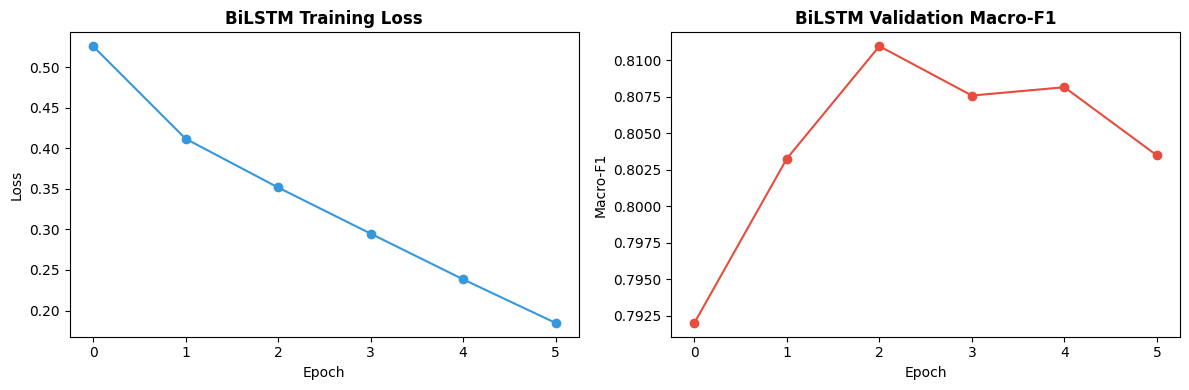

In [14]:
# ── Plot training curves ───────────────────────────────────────────────────
if len(history["train_loss"]) > 0 and len(history["val_f1"]) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], marker="o", color="#3498db")
    axes[0].set_title("BiLSTM Training Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    axes[1].plot(history["val_f1"], marker="o", color="#e74c3c")
    axes[1].set_title("BiLSTM Validation Macro-F1", fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Macro-F1")

    plt.tight_layout()
    plt.savefig("../outputs/baselines/bilstm_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠️ No training history to plot. Run training cell first.")


BiLSTM — test
  Accuracy    : 0.8097
  Macro-F1    : 0.8091  ← PRIMARY METRIC
  Weighted-F1 : 0.8092
  MCC         : 0.6225
  AUROC       : 0.8921

              precision    recall  f1-score   support

         0.0     0.7821    0.8612    0.8198      4740
         1.0     0.8439    0.7578    0.7985      4694

    accuracy                         0.8097      9434
   macro avg     0.8130    0.8095    0.8091      9434
weighted avg     0.8129    0.8097    0.8092      9434



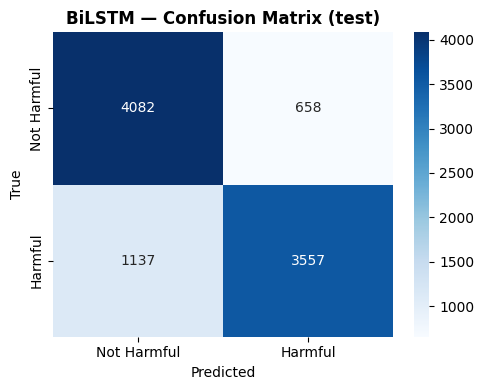

In [15]:
# ── Evaluate BiLSTM on test set ────────────────────────────────────────────
best_model_path = "../outputs/baselines/bilstm_best.pt"

if os.path.exists(best_model_path):
    model_lstm.load_state_dict(torch.load(best_model_path, map_location=device))
    model_lstm.eval()
else:
    print(f"⚠️ Best model not found at {best_model_path}. Training may not have completed successfully.")
    print("Using current model state...")

test_preds = []
test_probs = []
test_true = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        logits = model_lstm(batch_x)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = probs.argmax(-1)
        test_preds.extend(preds)
        test_probs.extend(probs)
        test_true.extend(batch_y.numpy())

# Only evaluate if we have predictions
if len(test_preds) > 0:
    evaluate_model("BiLSTM", np.array(test_true), np.array(test_preds), np.array(test_probs))
else:
    print("⚠️ No test predictions generated. Check model and data loading.")

## 4 — Baseline Results Summary


BASELINE RESULTS SUMMARY
                       model split  accuracy  macro_f1  weighted_f1    mcc  auroc
TF-IDF + Logistic Regression  test    0.8513    0.8511       0.8512 0.7034 0.9307
                TF-IDF + SVM  test    0.8482    0.8481       0.8481 0.6973 0.9255
      TF-IDF + Random Forest  test    0.8284    0.8283       0.8283 0.6572 0.9137
                      BiLSTM  test    0.8097    0.8091       0.8092 0.6225 0.8921

✅ Saved: ../outputs/baselines/baseline_results.csv


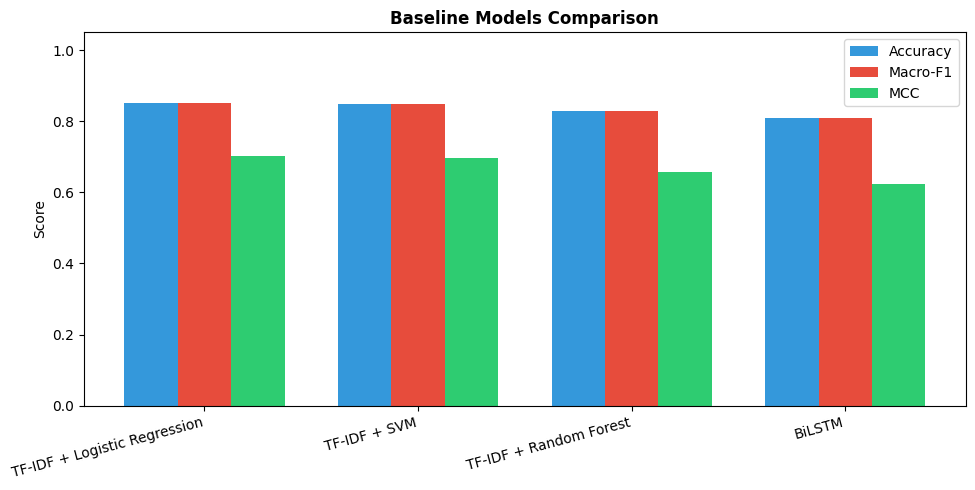

In [16]:
# ── Summary table ──────────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
print("\n" + "=" * 70)
print("BASELINE RESULTS SUMMARY")
print("=" * 70)
print(results_df.to_string(index=False))

# Save
results_df.to_csv("../outputs/baselines/baseline_results.csv", index=False)
print(f"\n✅ Saved: ../outputs/baselines/baseline_results.csv")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
test_results = results_df[results_df["split"] == "test"]
x = range(len(test_results))
width = 0.25
ax.bar([i - width for i in x], test_results["accuracy"], width, label="Accuracy", color="#3498db")
ax.bar(x, test_results["macro_f1"], width, label="Macro-F1", color="#e74c3c")
ax.bar([i + width for i in x], test_results["mcc"], width, label="MCC", color="#2ecc71")
ax.set_xticks(x)
ax.set_xticklabels(test_results["model"], rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_title("Baseline Models Comparison", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("../outputs/baselines/baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()



---
**Next:** Notebook `05_transformer_finetuning.ipynb` — Fine-tune BanglaBERT, MuRIL, and XLM-R with multi-task heads.